C:\Users\ben\AppData\Local\Temp\ipykernel_11800\2591877551.py:23: RuntimeWarning: divide by zero encountered in divide
  Se = Sa / (2 * np.pi * f)**4


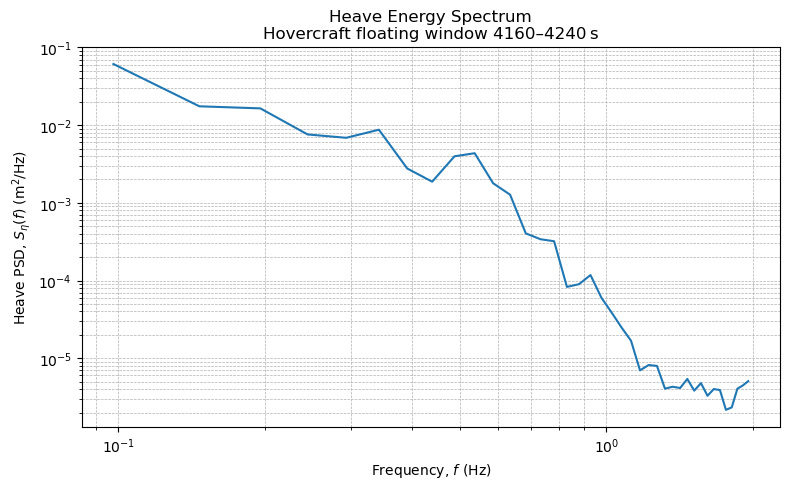

                             Metric  Value
  Significant wave height $H_s$ (m)  0.287
              Peak period $T_p$ (s)  10.24
Mean zero-crossing period $T_z$ (s)    3.5
                     Sea-state code      2
              Sea-state description Smooth


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

# Load the data
file_path = './Sensor_3/accel_014_Floating_on_sea_and_takeoff.csv'
df = pd.read_csv(file_path)

# Select the floating window
window_df = df[(df['time_from_sync'] >= 4160) & (df['time_from_sync'] <= 4240)].copy()

# Compute vertical acceleration assuming x-axis ≈ vertical
g = 9.81
az = window_df['x'].values * g - g
az = az - az.mean()

# Welch PSD
fs = 200.0  # Hz (verified from data)
f, Sa = welch(az, fs=fs, window='hann', nperseg=4096, noverlap=2048, detrend='constant')

# Convert acceleration PSD to heave PSD
Se = Sa / (2 * np.pi * f)**4
# Remove DC component
f, Se = f[1:], Se[1:]

# Restrict to physically meaningful band (0.05–2 Hz)
band = (f >= 0.05) & (f <= 2.0)
f_band, Se_band = f[band], Se[band]

# Plot heave spectrum
plt.figure(figsize=(8, 5))
plt.loglog(f_band, Se_band)
plt.xlabel('Frequency, $f$ (Hz)')
plt.ylabel('Heave PSD, $S_\\eta(f)$ (m$^2$/Hz)')
plt.title('Heave Energy Spectrum\nHovercraft floating window 4160–4240 s')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Wave parameters
m0 = np.trapz(Se_band, f_band)
m2 = np.trapz(Se_band * f_band**2, f_band)
Hs = 4 * np.sqrt(m0)
Tp = 1 / f_band[np.argmax(Se_band)]
Tz = np.sqrt(m0 / m2)

# Sea-state classification (WMO/Douglas)
def sea_state(Hs):
    if Hs < 0.05: return 0, "Calm (glassy)"
    if Hs < 0.10: return 1, "Calm (rippled)"
    if Hs < 0.50: return 2, "Smooth"
    if Hs < 1.25: return 3, "Slight"
    if Hs < 2.50: return 4, "Moderate"
    if Hs < 4.00: return 5, "Rough"
    if Hs < 6.00: return 6, "Very rough"
    if Hs < 9.00: return 7, "High"
    if Hs < 14.0: return 8, "Very high"
    return 9, "Phenomenal"

state_code, state_desc = sea_state(Hs)

# Summary output
summary = pd.DataFrame({
    "Metric": [
        "Significant wave height $H_s$ (m)",
        "Peak period $T_p$ (s)",
        "Mean zero-crossing period $T_z$ (s)",
        "Sea-state code",
        "Sea-state description"
    ],
    "Value": [
        round(Hs, 3),
        round(Tp, 2),
        round(Tz, 2),
        state_code,
        state_desc
    ]
})

print(summary.to_string(index=False))

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from pathlib import Path

# ------------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------------
SENSORS = {
    "Sensor_3": 200,
    "Sensor_4": 200,
    "Sensor_5": 200,
    "Sensor_wb": 100,         # wave-buoy, lower rate
}
file_template = "./{sensor}/accel_014_Floating_on_sea_and_takeoff.csv"
T_WINDOW = (4160, 4240)       # seconds from 'time_from_sync'
g = 9.81                      # m s-2
F_BAND = (0.05, 2.0)          # Hz, physically meaningful wave band
# ------------------------------------------------------------------

def sea_state(Hs):
    """Return (Douglas code, description) for a given significant wave height."""
    bins = [0.05, 0.1, 0.5, 1.25, 2.5, 4, 6, 9, 14]
    desc = ["Calm (glassy)", "Calm (rippled)", "Smooth", "Slight", "Moderate",
            "Rough", "Very rough", "High", "Very high", "Phenomenal"]
    idx = np.digitize(Hs, bins)
    return idx, desc[idx]

results, spectra = [], {}

for sensor, fs in SENSORS.items():
    # ------------------------------------------------------------------
    # LOAD & WINDOW
    # ------------------------------------------------------------------
    fp = Path(file_template.format(sensor=sensor))
    if not fp.exists():
        raise FileNotFoundError(f"Missing file for {sensor}: {fp}")
    df = pd.read_csv(fp)
    win = df.query(" @T_WINDOW[0] <= time_from_sync <= @T_WINDOW[1] ").copy()

    # ------------------------------------------------------------------
    # VERTICAL ACCELERATION (x-axis ≈ vertical)
    # ------------------------------------------------------------------
    az = win["x"].to_numpy(dtype=float) * g - g          # convert to m s-2, remove 1 g
    az -= az.mean()                                      # de-bias

    # ------------------------------------------------------------------
    # WELCH POWER-SPECTRAL DENSITY
    # ------------------------------------------------------------------
    # Pick an FFT length ≈ 20 s long and next-power-of-two
    nperseg = 2 ** int(np.round(np.log2(fs * 20)))
    f, Sa = welch(az, fs=fs, window="hann", nperseg=nperseg,
                  noverlap=nperseg // 2, detrend="constant")

    # ------------------------------------------------------------------
    # ACC -> HEAVE PSD AND BAND-PASS
    # ------------------------------------------------------------------
    Se = Sa / (2 * np.pi * f) ** 4
    f, Se = f[1:], Se[1:]                                     # drop DC
    band = (F_BAND[0] <= f) & (f <= F_BAND[1])
    f_band, Se_band = f[band], Se[band]
    spectra[sensor] = (f_band, Se_band)

    # ------------------------------------------------------------------
    # WAVE PARAMETERS
    # ------------------------------------------------------------------
    m0 = np.trapz(Se_band, f_band)
    m2 = np.trapz(Se_band * f_band ** 2, f_band)
    Hs = 4 * np.sqrt(m0)
    Tp = 1 / f_band[np.argmax(Se_band)]
    Tz = np.sqrt(m0 / m2)
    code, desc = sea_state(Hs)

    results.append(dict(Sensor=sensor, fs_Hz=fs,
                        Hs_m=Hs, Tp_s=Tp, Tz_s=Tz,
                        Sea_state_code=code, Sea_state_desc=desc))

# ----------------------------------------------------------------------
# PLOT -– OVERLAID HEAVE ENERGY SPECTRA
# ----------------------------------------------------------------------
plt.figure(figsize=(8, 5))
for sensor, (f_band, Se_band) in spectra.items():
    plt.loglog(f_band, Se_band, label=f"{sensor}  fs={SENSORS[sensor]} Hz")
plt.xlabel("Frequency  $f$  (Hz)")
plt.ylabel("Heave PSD  $S_η(f)$  (m$^{2}$/Hz)")
plt.title("Hovercraft floating 4160–4240 s — Heave Energy Spectra")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# SUMMARY TABLE
# ----------------------------------------------------------------------
summary = (pd
           .DataFrame(results)
           .assign(Hs_m=lambda d: d.Hs_m.round(3),
                   Tp_s=lambda d: d.Tp_s.round(2),
                   Tz_s=lambda d: d.Tz_s.round(2))
           .set_index("Sensor"))

print("\nWave-parameter summary")
print(summary[["Hs_m", "Tp_s", "Tz_s", "Sea_state_code", "Sea_state_desc"]]
      .to_string())


C:\Users\ben\AppData\Local\Temp\ipykernel_11800\253431696.py:59: RuntimeWarning: divide by zero encountered in divide
  Se = Sa / (2 * np.pi * f) ** 4
C:\Users\ben\AppData\Local\Temp\ipykernel_11800\253431696.py:46: RuntimeWarning: Mean of empty slice.
  az -= az.mean()                                      # de-bias
c:\Users\ben\.conda\envs\hovercraft\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: attempt to get argmax of an empty sequence

⚠️ No data found in the specified window for Sensor_wnb. Skipping.


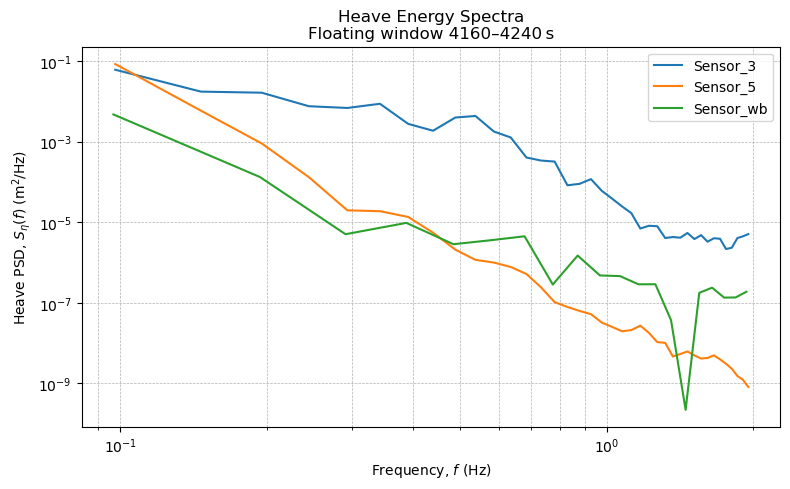

    Sensor  Significant wave height $H_s$ (m)  Peak period $T_p$ (s)  Mean zero-crossing period $T_z$ (s)  Sea-state code Sea-state description
  Sensor_3                              0.287                  10.24                                 3.50             2.0                Smooth
Sensor_wnb                                NaN                    NaN                                  NaN             NaN     No data in window
  Sensor_5                              0.196                  10.24                                 9.21             2.0                Smooth
 Sensor_wb                              0.063                  10.33                                 8.12             1.0        Calm (rippled)


In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

# Sea-state classification (WMO/Douglas)
def sea_state(Hs):
    if Hs < 0.05: return 0, "Calm (glassy)"
    if Hs < 0.10: return 1, "Calm (rippled)"
    if Hs < 0.50: return 2, "Smooth"
    if Hs < 1.25: return 3, "Slight"
    if Hs < 2.50: return 4, "Moderate"
    if Hs < 4.00: return 5, "Rough"
    if Hs < 6.00: return 6, "Very rough"
    if Hs < 9.00: return 7, "High"
    if Hs < 14.0: return 8, "Very high"
    return 9, "Phenomenal"

# Define sensors with file paths and sampling frequencies
sensors = [
    {'name': 'Sensor_3', 'file': './Sensor_3/accel_014_Floating_on_sea_and_takeoff.csv', 'fs': 200},
    {'name': 'Sensor_wnb', 'file': './Sensor_4/accel_014_Floating_on_sea_and_takeoff.csv', 'fs': 200},
    {'name': 'Sensor_5', 'file': './Sensor_5/accel_014_Floating_on_sea_and_takeoff.csv', 'fs': 200},
    {'name': 'Sensor_wb', 'file': './Sensor_wb/accel_014_Floating_on_sea_and_takeoff.csv', 'fs': 100}
]

g = 9.81
sensor_results = []

# Plot setup
plt.figure(figsize=(8, 5))

# Loop over all sensors
for sensor in sensors:
    name = sensor['name']
    file_path = sensor['file']
    fs = sensor['fs']

    # Load the data
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"❌ File not found for {name}. Skipping.")
        sensor_results.append({
            'Sensor': name,
            'Significant wave height $H_s$ (m)': np.nan,
            'Peak period $T_p$ (s)': np.nan,
            'Mean zero-crossing period $T_z$ (s)': np.nan,
            'Sea-state code': np.nan,
            'Sea-state description': "Invalid data"
        })
        continue

    # Select the floating window
    window_df = df[(df['time_from_sync'] >= 4160) & (df['time_from_sync'] <= 4240)].copy()

    if window_df.empty:
        print(f"⚠️ No data found in the specified window for {name}. Skipping.")
        sensor_results.append({
            'Sensor': name,
            'Significant wave height $H_s$ (m)': np.nan,
            'Peak period $T_p$ (s)': np.nan,
            'Mean zero-crossing period $T_z$ (s)': np.nan,
            'Sea-state code': np.nan,
            'Sea-state description': "No data in window"
        })
        continue

    # Compute vertical acceleration (in m/s²)
    az = window_df['x'].values * g - g
    az = az - az.mean()

    # Set Welch parameters based on data length
    nperseg = min(4096, len(az))
    noverlap = int(nperseg / 2)  # 50% overlap

    if noverlap >= nperseg:
        noverlap = nperseg - 1  # Ensure overlap < nperseg

    # Welch's method for Power Spectral Density
    f, Sa = welch(az, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap, detrend='constant')

    # Remove DC component
    f = f[1:]
    Sa = Sa[1:]

    # Convert acceleration PSD to heave PSD
    Se = Sa / (2 * np.pi * f)**4

    # Restrict to the physically meaningful band (0.05–2 Hz)
    band = (f >= 0.05) & (f <= 2.0)
    f_band = f[band]
    Se_band = Se[band]

    if len(f_band) == 0:
        print(f"⚠️ No frequencies found in the 0.05–2 Hz band for {name}. Skipping.")
        sensor_results.append({
            'Sensor': name,
            'Significant wave height $H_s$ (m)': np.nan,
            'Peak period $T_p$ (s)': np.nan,
            'Mean zero-crossing period $T_z$ (s)': np.nan,
            'Sea-state code': np.nan,
            'Sea-state description': "No frequencies in band"
        })
        continue

    # Compute spectral moments
    m0 = np.trapz(Se_band, f_band)
    m2 = np.trapz(Se_band * f_band**2, f_band)

    # Calculate wave parameters
    Hs = 4 * np.sqrt(m0)
    Tp = 1 / f_band[np.argmax(Se_band)]  # Inverse of peak frequency
    Tz = np.sqrt(m0 / m2)  # Zero-crossing period

    # Determine sea state
    state_code, state_desc = sea_state(Hs)

    # Store results
    sensor_results.append({
        'Sensor': name,
        'Significant wave height $H_s$ (m)': round(Hs, 3),
        'Peak period $T_p$ (s)': round(Tp, 2),
        'Mean zero-crossing period $T_z$ (s)': round(Tz, 2),
        'Sea-state code': state_code,
        'Sea-state description': state_desc
    })

    # Plot the heave spectrum
    plt.loglog(f_band, Se_band, label=name)

# Final plot formatting
plt.xlabel('Frequency, $f$ (Hz)')
plt.ylabel('Heave PSD, $S_\\eta(f)$ (m$^2$/Hz)')
plt.title('Heave Energy Spectra\nFloating window 4160–4240 s')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Create and print summary table
summary_df = pd.DataFrame(sensor_results)
print(summary_df.to_string(index=False))

⚠️  Sensor_4: no data in the chosen time window; skipping.


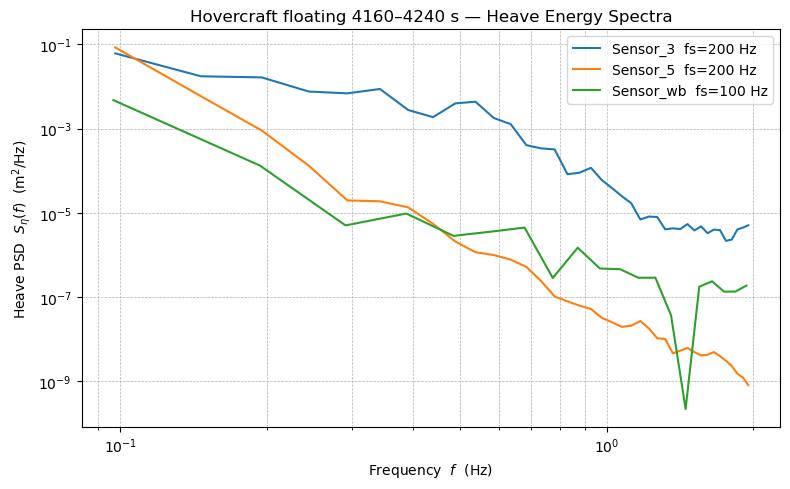


Wave-parameter summary
            Hs_m   Tp_s  Tz_s  Sea_state_code  Sea_state_desc
Sensor                                                       
Sensor_3   0.287  10.24  3.50               2          Smooth
Sensor_5   0.196  10.24  9.21               2          Smooth
Sensor_wb  0.063  10.33  8.12               1  Calm (rippled)


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from pathlib import Path

# ------------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------------
SENSORS = {
    "Sensor_3": 200,
    "Sensor_4": 200,
    "Sensor_5": 200,
    "Sensor_wb": 100,
}

file_template = "./{sensor}/accel_014_Floating_on_sea_and_takeoff.csv"
T_WINDOW  = (4160, 4240)        # s from 'time_from_sync'
g         = 9.81                # m s⁻²
F_BAND    = (0.05, 2.0)         # Hz – target wave band
# ------------------------------------------------------------------

def sea_state(Hs):
    bins = [0.05, 0.1, 0.5, 1.25, 2.5, 4, 6, 9, 14]
    desc = ["Calm (glassy)", "Calm (rippled)", "Smooth", "Slight",
            "Moderate", "Rough", "Very rough", "High", "Very high",
            "Phenomenal"]
    i = np.digitize(Hs, bins)
    return i, desc[i]

results, spectra = [], {}

for sensor, fs in SENSORS.items():
    # --------------------------------------------------------------
    # LOAD
    # --------------------------------------------------------------
    fp = Path(file_template.format(sensor=sensor))
    if not fp.exists():
        print(f"❌  {sensor}: file not found → {fp}")
        continue

    df  = pd.read_csv(fp)
    win = df.query("@T_WINDOW[0] <= time_from_sync <= @T_WINDOW[1]").copy()
    if win.empty:
        print(f"⚠️  {sensor}: no data in the chosen time window; skipping.")
        continue

    # --------------------------------------------------------------
    # ACC → heave
    # --------------------------------------------------------------
    az = win["x"].to_numpy(dtype=float) * g - g
    az -= az.mean()

    nperseg = 2**int(np.round(np.log2(fs * 20)))
    nperseg = min(nperseg, len(az))
    f, Sa = welch(az, fs=fs, window="hann",
                  nperseg=nperseg, noverlap=nperseg//2,
                  detrend="constant")

    # Drop DC
    if f.size <= 1:
        print(f"⚠️  {sensor}: spectrum has no non-zero frequency bins; "
              "skipping this sensor.")
        continue
    Se = Sa[1:] / (2 * np.pi * f[1:])**4
    f  = f[1:]

    # --------------------------------------------------------------
    # Pick band, with safety-net
    # --------------------------------------------------------------
    band = (F_BAND[0] <= f) & (f <= F_BAND[1])
    if not np.any(band):
        print(f"⚠️  {sensor}: no bins in {F_BAND[0]}–{F_BAND[1]} Hz "
              f"(min non-zero ≈ {f[0]:.3f} Hz). Using all bins.")
        band = slice(None)

    f_band, Se_band = f[band], Se[band]
    if f_band.size == 0 or np.all(Se_band == 0):
        print(f"⚠️  {sensor}: insufficient spectral energy; skipping.")
        continue

    spectra[sensor] = (f_band, Se_band)

    # --------------------------------------------------------------
    # Wave parameters
    # --------------------------------------------------------------
    m0 = np.trapz(Se_band, f_band)
    m2 = np.trapz(Se_band * f_band**2, f_band)
    if m0 == 0 or m2 == 0:
        print(f"⚠️  {sensor}: zero spectral moments; skipping.")
        continue

    Hs = 4 * np.sqrt(m0)
    Tp = 1 / f_band[np.argmax(Se_band)]
    Tz = np.sqrt(m0 / m2)
    code, desc = sea_state(Hs)

    results.append(dict(Sensor=sensor, fs_Hz=fs,
                        Hs_m=Hs, Tp_s=Tp, Tz_s=Tz,
                        Sea_state_code=code, Sea_state_desc=desc))

# ------------------------------------------------------------------
# PLOT
# ------------------------------------------------------------------
if spectra:
    plt.figure(figsize=(8, 5))
    for sensor, (f_band, Se_band) in spectra.items():
        plt.loglog(f_band, Se_band, label=f"{sensor}  fs={SENSORS[sensor]} Hz")
    plt.xlabel("Frequency  $f$  (Hz)")
    plt.ylabel("Heave PSD  $S_η(f)$  (m$^{2}$/Hz)")
    plt.title("Hovercraft floating 4160–4240 s — Heave Energy Spectra")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No spectra to plot.")

# ------------------------------------------------------------------
# SUMMARY TABLE
# ------------------------------------------------------------------
if results:
    summary = (pd.DataFrame(results)
                 .assign(Hs_m=lambda d: d.Hs_m.round(3),
                         Tp_s=lambda d: d.Tp_s.round(2),
                         Tz_s=lambda d: d.Tz_s.round(2))
                 .set_index("Sensor"))

    print("\nWave-parameter summary")
    print(summary[["Hs_m", "Tp_s", "Tz_s",
                   "Sea_state_code", "Sea_state_desc"]].to_string())
else:
    print("No valid wave-parameter results.")
